## Credit Risk Classification Code

Group Members: Matheus Santos Gomes, Joaquin Hidalgo-Estrada, Rajan Jinadra, Natiana Urdaneta Barazarte


In [47]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# !pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/matheusmsgomes/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [49]:
import os

# look at all data files
print(os.listdir(path))

['UCI_Credit_Card.csv']


In [50]:
# ebuild full path and load it
file_name = "UCI_Credit_Card.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

## DATA CLEANING

In [51]:
# initial inspection of data frame
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

In [52]:
# check missing values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

- Pay close attention to default.payment.next.month, PAY_AMT2, and EDUCATION for possible issues
- drop ID as it gives no predictive power (index variable)
- no missing values or non-plausible values in the data
- categorical variables are already in numerical form. no need to format

In [53]:
# drop ID column
df = df.drop('ID', axis=1)

In [54]:
# rename columns for clarity
df = df.rename(columns={
    "default.payment.next.month": "default",
    "PAY_0": "PAY_1"
})

In [55]:
# remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [56]:
# merge 0, 5, and 6 since they are both "unknown" category
# keep "unknown" separate from "other"
df["EDUCATION"] = df["EDUCATION"].replace({0: 5, 5: 5, 6: 5})

# verify
df["EDUCATION"].value_counts()

EDUCATION
2    14019
1    10563
3     4915
5      345
4      123
Name: count, dtype: int64

In [57]:
# MARRIAGE cleanup
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Exploratory Data Analysis

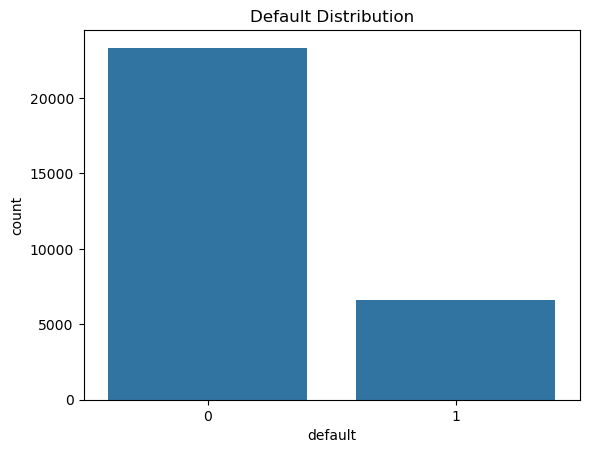

In [58]:
# check target variable distribution
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

- target variable imbalance. address inmediately to avoid bias in the model
- use resampling technique or other

In [59]:
# understand class imbalance
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

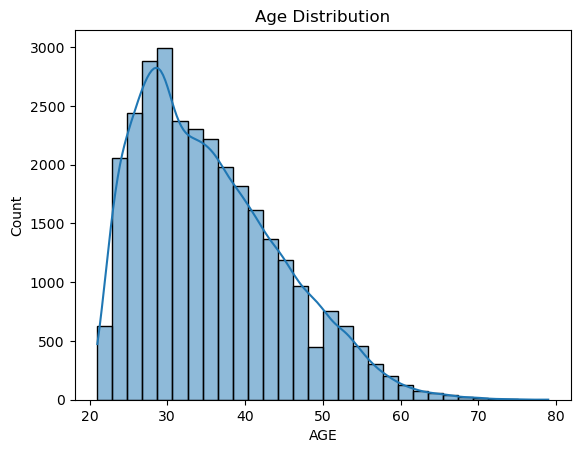

In [60]:
# AGE distribution
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

- skewness to the right. consider transformation

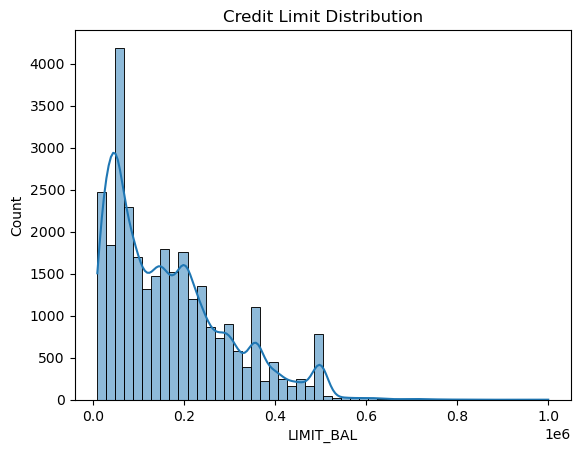

In [61]:
# credit limit distribution
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True)
plt.title("Credit Limit Distribution")
plt.show()

- once again skewness to the right. consdier transformation.
- more unstable than age distribution

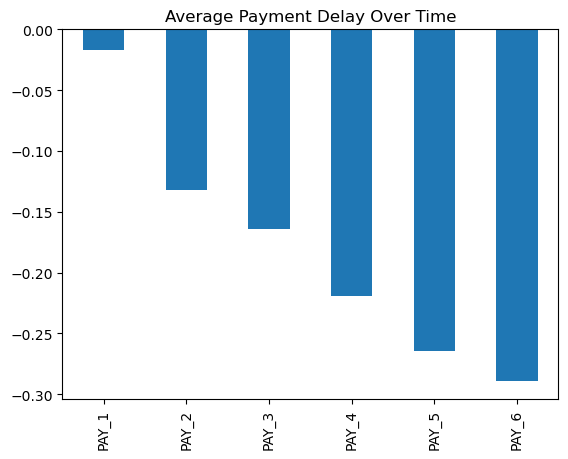

In [62]:
# payment status each month analysis
pay_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

df[pay_cols].mean().plot(kind="bar")
plt.title("Average Payment Delay Over Time")
plt.show()

- this graph tells us that loaners tend to struggle more and more as they grow debt continuously each month

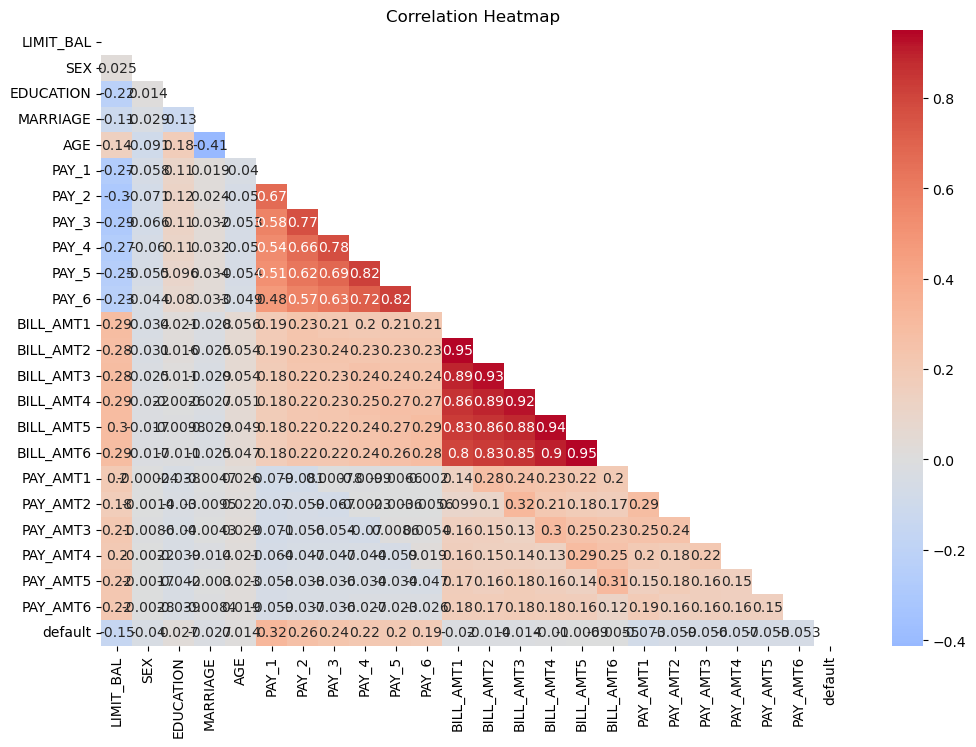

In [63]:
# heatmap correlation
plt.figure(figsize=(12,8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

- be mindful of potential multicollinearity issues.
- high correlation between features makes it impossible to determine the individual importance of variables. interpretability problem


## FEATURE ENGINEERING

In [64]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
            "BILL_AMT4","BILL_AMT5","BILL_AMT6"]

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

In [65]:
# total bill amount
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

In [66]:
# total payment amount
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)

In [67]:
# payment ratio (signal)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1) # +1 to avoid division by 0

In [68]:
# credit utilization (debt to limit percentage)
df["UTILIZATION"] = df["TOTAL_BILL"] / (df["LIMIT_BAL"] + 1)

In [69]:
# log transform for skewed variables
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])
df["AGE_LOG"] = np.log1p(df["AGE"])

In [70]:
# df.to_csv(file_path, index=False)

In [71]:
'''
folder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")
df.to_csv(file_path, index=False)
print(file_path)
'''

'\nfolder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"\nfile_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")\ndf.to_csv(file_path, index=False)\nprint(file_path)\n'

In [72]:
# print(os.listdir(folder_path))

Interaction Variables to Create

In [73]:
# Repayment Behavior Features

# average delay across 6 months
df["PAY_AVG"] = df[pay_cols].mean(axis=1)

# worst delay ever recorded
df["PAY_MAX"] = df[pay_cols].max(axis=1)

# recent worsening trend
df["PAY_TREND"] = df["PAY_1"] - df["PAY_6"]

These capture:

ΓÇó consistent lateness\
ΓÇó severe lateness\
ΓÇó behavior getting worse recently

In [74]:
# Debt Behavior Features

# average monthly bill
df["AVG_BILL"] = df[bill_cols].mean(axis=1)

# bill volatility
df["BILL_STD"] = df[bill_cols].std(axis=1)

# debt increasing recently
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]

In [75]:
# Payment Behavior Features

# average monthly payment
df["AVG_PAY"] = df[pay_amt_cols].mean(axis=1)

# payment consistency
df["PAY_STD"] = df[pay_amt_cols].std(axis=1)

In [76]:
# Best Interaction Terms
df["UTIL_X_PAY1"] = df["UTILIZATION"] * df["PAY_1"]
df["RATIO_X_PAY1"] = df["PAY_RATIO"] * df["PAY_1"]
df["LIMIT_X_UTIL"] = df["LIMIT_BAL_LOG"] * df["UTILIZATION"]
df["AGE_X_PAY1"] = df["AGE_LOG"] * df["PAY_1"]

In [77]:
# Getting CSV with new features/columns
folder_path = "/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")
df.to_csv(file_path, index=False)
print(file_path)

/Users/matheusmsgomes/Documents/Spring 2026/Stats Found AI and DS 2/STA4365_Project/cleaned_credit_data_v1.csv


In [78]:
# Checking which features matter most
corr_target = df.corr(numeric_only=True)["default"].sort_values(ascending=False)
print(corr_target.head(20))
print()
print(corr_target.tail(10))

default         1.000000
PAY_MAX         0.331082
PAY_1           0.324964
AGE_X_PAY1      0.323116
UTIL_X_PAY1     0.316637
PAY_AVG         0.281989
PAY_2           0.263656
PAY_3           0.235230
PAY_4           0.216551
PAY_5           0.204059
PAY_6           0.186740
PAY_TREND       0.129303
UTILIZATION     0.115449
LIMIT_X_UTIL    0.102899
EDUCATION       0.026979
AGE             0.013619
AGE_LOG         0.007301
RATIO_X_PAY1    0.003351
BILL_AMT6      -0.005469
BILL_AMT5      -0.006859
Name: default, dtype: float64

PAY_AMT3        -0.056319
PAY_AMT4        -0.056898
PAY_AMT2        -0.058643
PAY_AMT1        -0.073015
PAY_STD         -0.074123
BILL_STD        -0.079981
AVG_PAY         -0.102488
TOTAL_PAY       -0.102488
LIMIT_BAL       -0.153871
LIMIT_BAL_LOG   -0.173722
Name: default, dtype: float64


The output is telling: 
| Feature     | Correlation with Default |
| ----------- | ------------------------ |
| PAY_MAX     | **0.331**                |
| PAY_1       | 0.325                    |
| AGE_X_PAY1  | 0.323                    |
| UTIL_X_PAY1 | 0.317                    |
| PAY_AVG     | 0.282                    |

Interpretation:

ΓÇó PAY_MAX = Strongest Predictor

This means:The worst repayment status over 6 months matters more than any single month.

ΓÇó UTIL_X_PAY1 is Elite Feature

High utilization + recent late payment = strong risk.

ΓÇó GE_X_PAY1 Strong

Suggests age modifies repayment risk. Younger late payers may behave differently than older ones.

ΓÇó LIMIT_BAL Negative Correlation

Higher credit limits linked with lower default. Likely stronger credit profiles.

In [79]:
# Top Predictors:
top_features = [
    "PAY_MAX",
    "PAY_1",
    "AGE_X_PAY1",
    "UTIL_X_PAY1",
    "PAY_AVG",
    "PAY_2",
    "PAY_3",
    "PAY_TREND",
    "UTILIZATION",
    "LIMIT_BAL_LOG",
    "AVG_PAY"
]

## Logistic Regression Model

In [80]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


In [81]:
X = df[top_features]
y = df["default"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [82]:
# scale
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [83]:
# L1 - Lasso Logistic
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    max_iter=3000,
    C=1.0
)

l1_model.fit(X_train_s, y_train)
l1_probs = l1_model.predict_proba(X_test_s)[:,1]
l1_auc = roc_auc_score(y_test, l1_probs)

/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [84]:
# L2 - Ridge Logistic
l2_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=3000,
    C=1.0
)

l2_model.fit(X_train_s, y_train)
l2_probs = l2_model.predict_proba(X_test_s)[:,1]
l2_auc = roc_auc_score(y_test, l2_probs)

/opt/anaconda3/envs/clean_ds/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [85]:
print("L1 AUC:", round(l1_auc,4))
print("L2 AUC:", round(l2_auc,4))

L1 AUC: 0.7313
L2 AUC: 0.7312


Conclusion from Regularization Models:

ΓÇó Both models perform almost identically \
ΓÇó Your features are doing the heavy lifting \
ΓÇó Regularization type matters less than good feature engineering

Choosing L1 (Lasso)

ΓÇó same performance \
ΓÇó simpler model \
ΓÇó feature selection \
ΓÇó cleaner interpretation

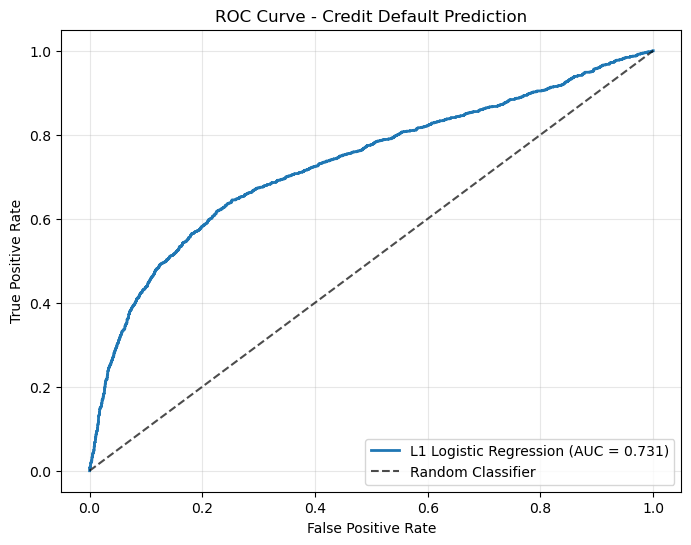

In [86]:
from sklearn.metrics import roc_curve

# Compute ROC points
fpr, tpr, thresholds = roc_curve(y_test, l1_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"L1 Logistic Regression (AUC = {l1_auc:.3f})"
)

# Random baseline
plt.plot([0,1], [0,1], 'k--', alpha=0.7, label="Random Classifier")

# Labels and style
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Default Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

In [87]:
# Checking which variable L1 selected
coef = pd.Series(l1_model.coef_[0], index=top_features)
coef.sort_values()

AGE_X_PAY1      -0.352197
AVG_PAY         -0.244634
LIMIT_BAL_LOG   -0.197594
UTILIZATION     -0.172685
PAY_2           -0.029240
PAY_3           -0.016362
PAY_AVG          0.000000
PAY_TREND        0.057846
PAY_1            0.334359
PAY_MAX          0.532117
UTIL_X_PAY1      0.579825
dtype: float64

The model judged PAY_AVG redundant

## Confusion Matrix and Precision/Recall Metrics

In [88]:
from sklearn.metrics import classification_report

for t in [0.50, 0.55, 0.60, 0.65, 0.70]:
    pred = (l1_probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, pred))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4667
           1       0.44      0.62      0.51      1326

    accuracy                           0.74      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.74      0.75      5993


Threshold = 0.55
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4667
           1       0.47      0.56      0.51      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.76      0.77      5993


Threshold = 0.6
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4667
           1       0.53      0.49      0.51      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.68      0.69      5993
weighted avg       0.7

After analyzing different thresholds, I chose threshold = 0.6 because:

Precision crosses 50% \
Recall still close to 50% \
Best balanced tradeoff \
Accuracy improved strongly


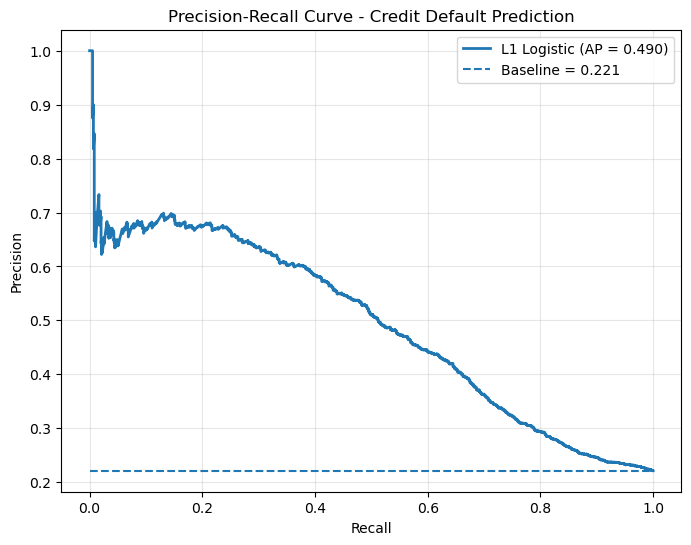

In [89]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, l1_probs)
ap = average_precision_score(y_test, l1_probs)

plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2,
         label=f"L1 Logistic (AP = {ap:.3f})")

# baseline = prevalence of positive class
baseline = y_test.mean()
plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Default Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Total test observations = 5993
Defaults (support for class 1) = 1326

So Baseline is:
1326 / 5993 = 0.221

So random targeting would give ~22% precision.

The model averages: 49%

In [90]:
# Prediction using thresholds
threshold = 0.60
l1_pred = (l1_probs >= threshold).astype(int)

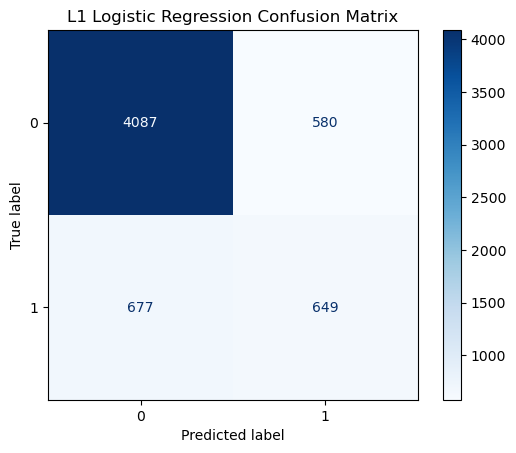

In [91]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, l1_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("L1 Logistic Regression Confusion Matrix")
plt.show()

Confusion Matrix gives us:

TN = 4087 (Borrowers who would not default, correctly classified as safe.)\
FP = 580 (Borrowers predicted to default, but actually would not.)\
FN = 677 (Borrowers predicted safe, but actually defaulted.)\
TP = 649 (Real defaulters correctly identified.)

## Naive Bayes

In [92]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


df = pd.read_csv(r"C:\Users\rajan\Downloads\cleaned_credit_data_v1.csv")

# Defining features and target
X = df.drop(columns=["default"])
y = df["default"]

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Trains the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)


y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1]


# Evaluating the default threshold (0.50)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Naive Bayes Results")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Evaluating with an adjusted threshold

threshold = 0.35
y_pred_adjusted = (y_prob >= threshold).astype(int)

adjusted_precision = precision_score(y_test, y_pred_adjusted, zero_division=0)
adjusted_recall = recall_score(y_test, y_pred_adjusted, zero_division=0)
adjusted_f1 = f1_score(y_test, y_pred_adjusted, zero_division=0)
adjusted_cm = confusion_matrix(y_test, y_pred_adjusted)

print(f"\nAdjusted Threshold Results (threshold = {threshold})")
print("=" * 40)
print(f"Precision: {adjusted_precision:.4f}")
print(f"Recall   : {adjusted_recall:.4f}")
print(f"F1 Score : {adjusted_f1:.4f}")

print("\nAdjusted Confusion Matrix:")
print(adjusted_cm)

#  Cross-validated ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_scaled_full = scaler.fit_transform(X)

cv_auc_scores = cross_val_score(
    GaussianNB(),
    X_scaled_full,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("\nCross-Validated ROC-AUC")
print("=" * 40)
print("Fold Scores:", cv_auc_scores)
print(f"Mean ROC-AUC: {cv_auc_scores.mean():.4f}")
print(f"Std Dev     : {cv_auc_scores.std():.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\rajan\\Downloads\\cleaned_credit_data_v1.csv'

## ARTIFICIAL NEURON NETWORK MODEL / FEED FORWARD

Approach:
- Use weighted loss from Pytorch to handle class imbalance internally without creating artifical data
- Use BCEWithLogitsLoss (binary cross-entropy)
- 

In [ ]:
#!pip install torch torchvision torchaudio

In [ ]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
import os
print(os.getcwd())

c:\Users\joaqu\OneDrive\Documents\Stat Fnd 2


In [ ]:
# load clean dataset
df = pd.read_csv("data/cleaned_credit_data_v1.csv")

In [ ]:
# list all columns
print(list(df.columns))

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default', 'TOTAL_BILL', 'TOTAL_PAY', 'PAY_RATIO', 'UTILIZATION', 'LIMIT_BAL_LOG', 'AGE_LOG', 'PAY_AVG', 'PAY_MAX', 'PAY_TREND', 'AVG_BILL', 'BILL_STD', 'BILL_TREND', 'AVG_PAY', 'PAY_STD', 'UTIL_X_PAY1', 'RATIO_X_PAY1', 'LIMIT_X_UTIL', 'AGE_X_PAY1']


In [ ]:
# split features and target
X = df.drop("default", axis=1)
y = df["default"]

In [ ]:
# train/test/split (very important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# standard scale all features (training only to avoid data leakage)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# convert to pytorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32)

In [ ]:
# handle class imbalance
num_pos = (y_train_tensor == 1).sum()
num_neg = (y_train_tensor == 0).sum()

pos_weight = num_neg / num_pos

In [ ]:
# create dataloader (mini-batch training)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# use batch_size 32 to get training stability and good generalization

In [ ]:
# build feed forward neural network
class CreditNN(nn.Module):
    def __init__(self, input_dim):
        super(CreditNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # No sigmoid
        )
    
    def forward(self, x):
        return self.model(x)

In [ ]:
# loss function and optimizer
model = CreditNN(input_dim=X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # sigmoid + loss combined

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # use learning rate 0.001

In [ ]:
train_losses = []
val_losses = []

epochs = 20

for epoch in range(epochs):
    
    # --------------------
    # TRAINING
    # --------------------
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # average train loss (IMPORTANT FIX)
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)


    # --------------------
    # VALIDATION
    # --------------------
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor).squeeze()
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())


    print(f"Epoch {epoch+1}: "
        f"Train Loss={avg_train_loss:.4f}, "
        f"Val Loss={val_loss.item():.4f}")

Epoch 1: Train Loss=0.7995, Val Loss=0.9245
Epoch 2: Train Loss=0.8009, Val Loss=0.9197
Epoch 3: Train Loss=0.7986, Val Loss=0.9224
Epoch 4: Train Loss=0.7955, Val Loss=0.9282
Epoch 5: Train Loss=0.7905, Val Loss=0.9366
Epoch 6: Train Loss=0.7948, Val Loss=0.9275
Epoch 7: Train Loss=0.7919, Val Loss=0.9295
Epoch 8: Train Loss=0.7875, Val Loss=0.9407
Epoch 9: Train Loss=0.7883, Val Loss=0.9292
Epoch 10: Train Loss=0.7876, Val Loss=0.9328
Epoch 11: Train Loss=0.7817, Val Loss=0.9379
Epoch 12: Train Loss=0.7847, Val Loss=0.9440
Epoch 13: Train Loss=0.7774, Val Loss=0.9471
Epoch 14: Train Loss=0.7811, Val Loss=0.9495
Epoch 15: Train Loss=0.7797, Val Loss=0.9369
Epoch 16: Train Loss=0.7791, Val Loss=0.9515
Epoch 17: Train Loss=0.7753, Val Loss=0.9523
Epoch 18: Train Loss=0.7696, Val Loss=0.9510
Epoch 19: Train Loss=0.7740, Val Loss=0.9705
Epoch 20: Train Loss=0.7785, Val Loss=0.9446


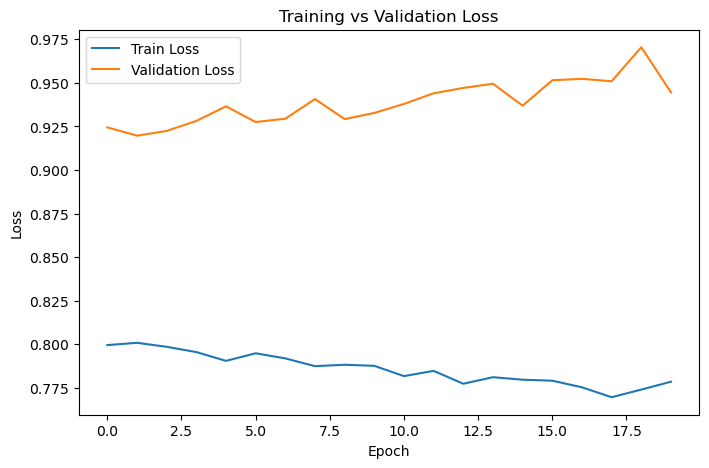

In [ ]:
# plot training vs validation loss
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
# evaluate model
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor).squeeze()
    probs = torch.sigmoid(logits)

- turn off gradient tracking. we are not training anymore.
- no need to compute gradients

In [ ]:
# threshold tuning
threshold = 0.3
preds = (probs > threshold).float()

we use threshold 0.3 because we want to catch more defaulters 
in an imbalanced dataset and increase recall

In [ ]:
# print metrics
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score

# convert tensors to numpy
y_true = y_test_tensor.numpy()
y_pred = preds.numpy()
y_probs = probs.numpy()

print(classification_report(y_true, y_pred))

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_probs))

              precision    recall  f1-score   support

         0.0       0.92      0.41      0.57      4667
         1.0       0.30      0.87      0.44      1326

    accuracy                           0.51      5993
   macro avg       0.61      0.64      0.51      5993
weighted avg       0.78      0.51      0.54      5993

Precision: 0.2962012320328542
Recall: 0.8702865761689291
ROC-AUC: 0.7664770874478584


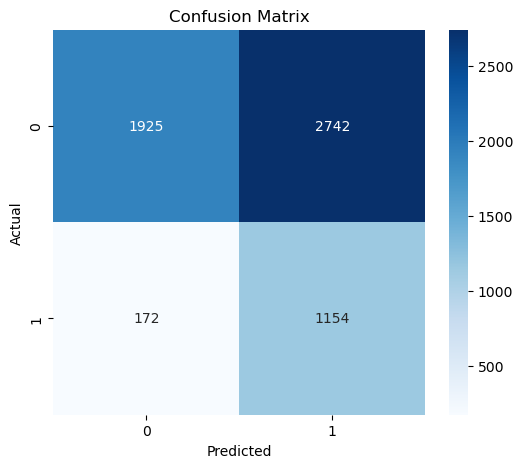

In [ ]:
# confusion matrix plot
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## interpretation
- the goal was accomplished: the model is very good at catching defaulters.
- problem: only 30% of predicted defaulters are actually defaulters.
- model flags many non-defaulters as a risk.

Model is optimized to catch defaulters at the cost of many false alarms.

Cause: low threshold and/or class weights

increase threshold to improve precision of the model using F1 optimal threshold tuning

In [ ]:
# find optimal threshold using F1 score
from sklearn.metrics import f1_score

thresholds = np.linspace(0.0, 1.0, 100)

f1_scores = []

for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_true, preds)
    f1_scores.append(f1)

In [ ]:
# identify best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1-score:", f1_scores[best_idx])


Best threshold: 0.5252525252525253
Best F1-score: 0.5234323432343234


In [ ]:
# final prediction threshold
final_preds = (y_probs > best_threshold).astype(int)

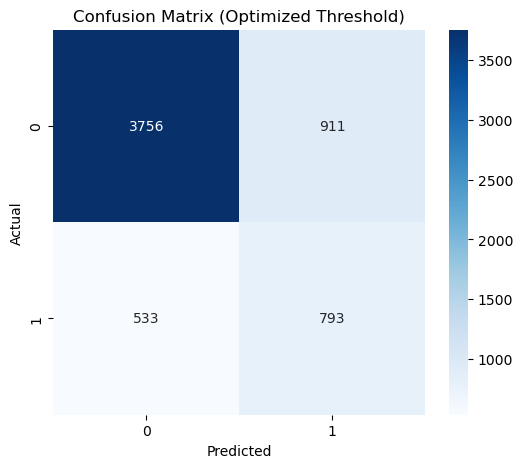

In [ ]:
# new classification matrix
y_true = y_test_tensor.numpy()
y_pred = final_preds

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized Threshold)")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# new classification report and metrics
print(classification_report(y_true, y_pred))
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      4667
         1.0       0.47      0.60      0.52      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.70      0.68      5993
weighted avg       0.78      0.76      0.77      5993

Accuracy: 0.7590522275988654
Precision: 0.4653755868544601
Recall: 0.5980392156862745


## interpretation

- When the model says ΓÇ£no defaultΓÇ¥, it is correct 88% of the time.
- It correctly identifies 80% of all safe customers

- When the model predicts default, it is correct 47% of the time
- It catches 60% of all actual defaulters

## XGBOOST

XGBoost Results - Default Threshold 0.50
Precision : 0.4657
Recall    : 0.6146
F1-Score  : 0.5299
ROC-AUC   : 0.7756

Confusion Matrix:
[[3732  935]
 [ 511  815]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4667
           1       0.47      0.61      0.53      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.71      0.68      5993
weighted avg       0.79      0.76      0.77      5993


XGBoost Results - Optimized Threshold
Best Threshold: 0.55
Precision     : 0.5075
Recall        : 0.5633
F1-Score      : 0.534
ROC-AUC       : 0.7756

Optimized Confusion Matrix:
[[3942  725]
 [ 579  747]]

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4667
           1       0.51      0.56      0.53      1326

    accuracy                           0.78      5993
   macro avg       0.69    

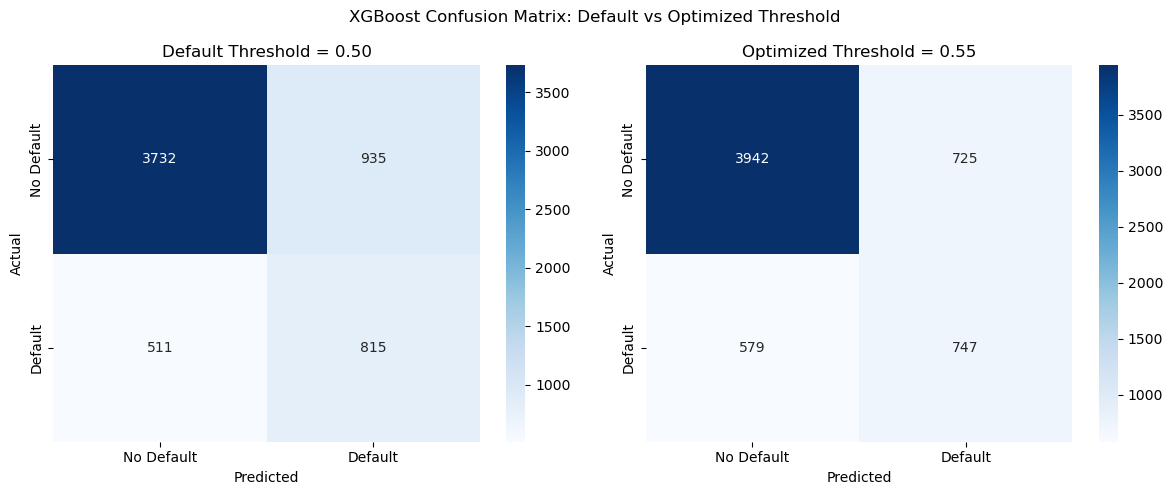

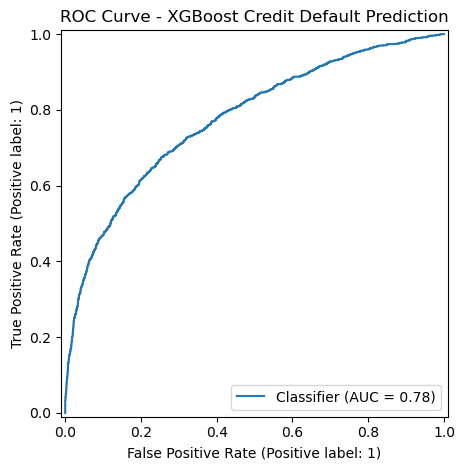


Top 10 Important Features:
       Feature  Importance
26   MAX_DELAY    0.351121
27  LATE_COUNT    0.143802
5        PAY_1    0.107697
23  TOTAL_BILL    0.025176
6        PAY_2    0.022030
24   TOTAL_PAY    0.020128
0    LIMIT_BAL    0.019314
11   BILL_AMT1    0.017947
18    PAY_AMT2    0.016462
25   PAY_RATIO    0.016219


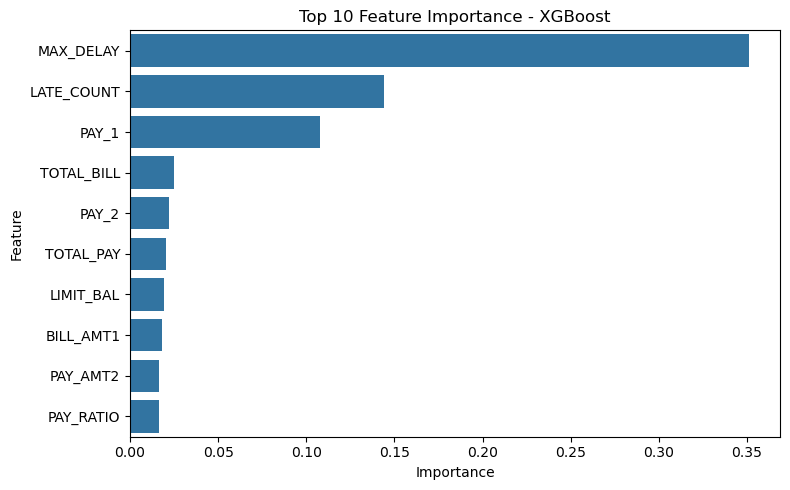

In [ ]:
# CreditRiskIQ - XGBoost Model 


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier


# 1. Load dataset
df = pd.read_csv("/Users/natianaurdaneta/Documents/10th Semester UCF/STA4365/UCI_Credit_Card.csv.zip")


# 2. Clean dataset
df = df.rename(columns={
    "default.payment.next.month": "DEFAULT",
    "PAY_0": "PAY_1"
})

if "ID" in df.columns:
    df = df.drop(columns=["ID"])

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

df = df.drop_duplicates()


# 3. Feature engineering
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

pay_status_cols = [
    "PAY_1", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1)
df["MAX_DELAY"] = df[pay_status_cols].max(axis=1)
df["LATE_COUNT"] = (df[pay_status_cols] > 0).sum(axis=1)


# 4. Define X and y
X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"]


# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 6. Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


# 7. Train XGBoost model
model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)


# 8. Predictions using default threshold 0.50
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.50).astype(int)


# 9. Default threshold metrics
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)
roc_auc = roc_auc_score(y_test, y_prob)
cm_default = confusion_matrix(y_test, y_pred_default)

print("XGBoost Results - Default Threshold 0.50")
print("========================================")
print("Precision :", round(precision_default, 4))
print("Recall    :", round(recall_default, 4))
print("F1-Score  :", round(f1_default, 4))
print("ROC-AUC   :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(cm_default)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))


# 10. Threshold optimization using F1-score
thresholds = np.arange(0.10, 0.90, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    current_f1 = f1_score(y_test, y_pred_threshold)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold


# 11. Optimized threshold metrics
y_pred_opt = (y_prob >= best_threshold).astype(int)

precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
cm_opt = confusion_matrix(y_test, y_pred_opt)

print("\nXGBoost Results - Optimized Threshold")
print("=====================================")
print("Best Threshold:", round(best_threshold, 2))
print("Precision     :", round(precision_opt, 4))
print("Recall        :", round(recall_opt, 4))
print("F1-Score      :", round(f1_opt, 4))
print("ROC-AUC       :", round(roc_auc, 4))

print("\nOptimized Confusion Matrix:")
print(cm_opt)

print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_opt))


# 12. Plot default vs optimized confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
axes[0].set_title("Default Threshold = 0.50")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
axes[1].set_title(f"Optimized Threshold = {round(best_threshold, 2)}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("XGBoost Confusion Matrix: Default vs Optimized Threshold")
plt.tight_layout()
plt.show()


# 13. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - XGBoost Credit Default Prediction")
plt.tight_layout()
plt.show()


# 14. Top 10 Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top10 = feature_importance.head(10)

print("\nTop 10 Important Features:")
print(top10)


plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

